<a href="https://colab.research.google.com/github/pranita30012005/ChronicDiseaseRiskAnalysis/blob/main/04_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

04 feature engineering

In [1]:
# ============================================================
# CELL 1 — Setup
# ============================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import joblib
import os

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [2]:
# ============================================================
# CELL 2 — Load data
# Swap this for pd.read_csv('/content/your_file.csv') to use your own data
# ============================================================
df = sns.load_dataset('titanic')
TARGET_COL = 'survived'   # <-- change this to your target column name

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# ============================================================
# CELL 3 — Drop unusable/redundant columns (domain reasoning, not stats)
# ============================================================
drop_cols = [c for c in ['deck', 'alive', 'embark_town'] if c in df.columns]
df = df.drop(columns=drop_cols)
print(f"Dropped: {drop_cols}")
df.head()

Dropped: ['deck', 'alive', 'embark_town']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,True


In [4]:
# ============================================================
# CELL 4 — Train/test split BEFORE any scaling/encoding (avoid leakage)
# ============================================================
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (712, 11)
Test shape : (179, 11)


In [5]:
# ============================================================
# CELL 5 — Identify column types
# ============================================================
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Normalize dtype: mixing bool + string columns can break SimpleImputer
X_train = X_train.copy()
X_test = X_test.copy()
X_train[categorical_cols] = X_train[categorical_cols].astype(object)
X_test[categorical_cols] = X_test[categorical_cols].astype(object)

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical columns: ['sex', 'embarked', 'class', 'who', 'adult_male', 'alone']


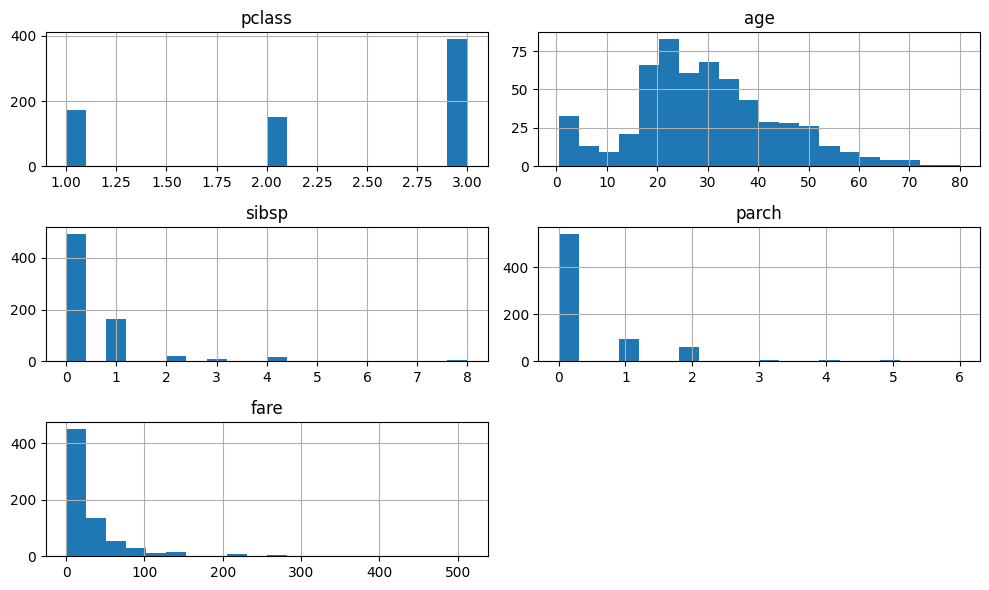

In [6]:
# ============================================================
# CELL 6 — Visualize distributions before scaling
# ============================================================
X_train[numeric_cols].hist(figsize=(10, 6), bins=20)
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7 — Build preprocessing pipeline, fit on TRAIN ONLY
# ============================================================
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)   # fit + transform
X_test_processed = preprocessor.transform(X_test)          # transform ONLY

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)

Processed train shape: (712, 20)
Processed test shape : (179, 20)


In [8]:
# ============================================================
# CELL 8 — Recover readable feature names
# ============================================================
feature_names = (
    numeric_cols +
    list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
)

X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

X_train_df.head()

,pclass,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,who_child,who_man,who_woman,adult_male_False,adult_male_True,alone_False,alone_True
692,0.829568,-0.081135,-0.465084,-0.466183,0.513812,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
481,-0.370945,-0.081135,-0.465084,-0.466183,-0.662563,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
527,-1.571457,-0.081135,-0.465084,-0.466183,3.955399,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
855,0.829568,-0.887827,-0.465084,0.727782,-0.467874,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
801,-0.370945,0.110934,0.478335,0.727782,-0.115977,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


Highly correlated feature pairs (|corr| > 0.9):
  sex_male <-> sex_female: 1.00
  class_Third <-> pclass: 0.92
  who_man <-> sex_female: 0.91
  who_man <-> sex_male: 0.91
  adult_male_False <-> sex_female: 0.91
  adult_male_False <-> sex_male: 0.91
  adult_male_False <-> who_man: 1.00
  adult_male_True <-> sex_female: 0.91
  adult_male_True <-> sex_male: 0.91
  adult_male_True <-> who_man: 1.00
  adult_male_True <-> adult_male_False: 1.00
  alone_True <-> alone_False: 1.00

Candidate columns to drop: ['sex_female', 'pclass', 'who_man', 'adult_male_False', 'alone_False', 'sex_male']


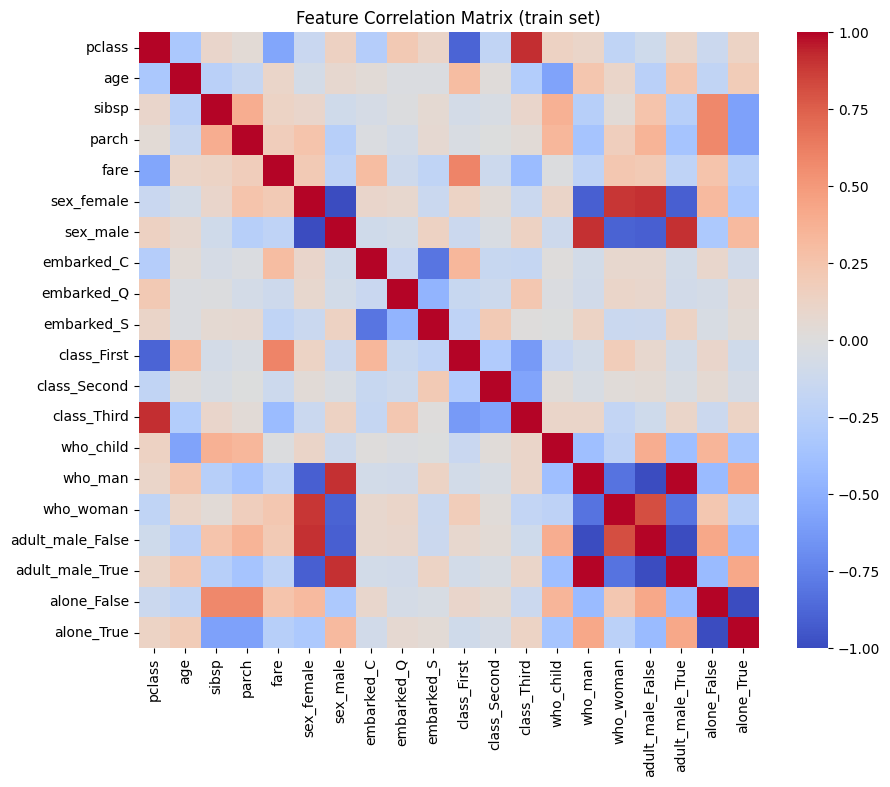

In [9]:
# ============================================================
# CELL 9 — Correlation-based screening (checked against importance later)
# ============================================================
corr_matrix = X_train_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(col, row, upper.loc[row, col])
                    for col in upper.columns for row in upper.index
                    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.9]

print("Highly correlated feature pairs (|corr| > 0.9):")
for a, b, v in high_corr_pairs:
    print(f"  {a} <-> {b}: {v:.2f}")

to_drop = list(set(pair[1] for pair in high_corr_pairs))
print("\nCandidate columns to drop:", to_drop)

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Feature Correlation Matrix (train set)')
plt.show()

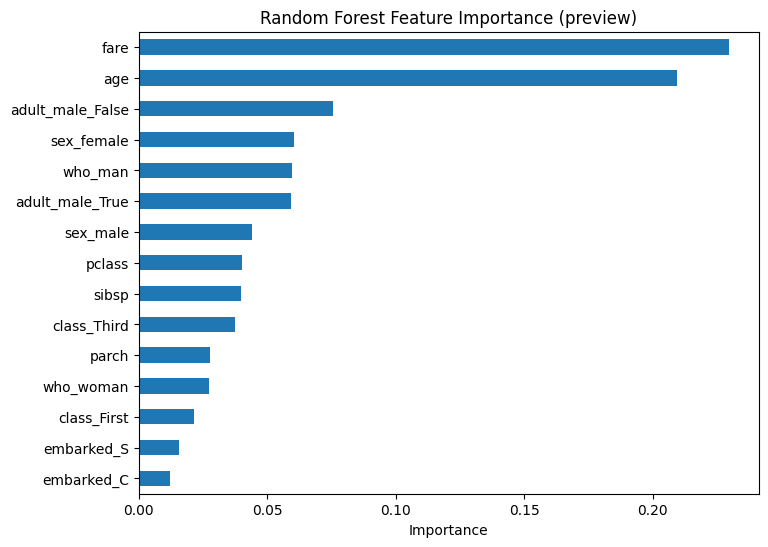

,0
fare,0.229669
age,0.209510
adult_male_False,0.075546
sex_female,0.060437
who_man,0.059650
adult_male_True,0.059097
sex_male,0.043937
pclass,0.040093
sibsp,0.039762
class_Third,0.037345


In [10]:
# ============================================================
# CELL 10 — Feature importance preview (Random Forest)
# ============================================================
rf_preview = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_preview.fit(X_train_df, y_train)

importances = pd.Series(rf_preview.feature_importances_, index=X_train_df.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance (preview)')
plt.xlabel('Importance')
plt.show()

importances.head(15)

In [14]:
# ============================================================
# CELL 11 — Finalize feature matrix (drop only if corr AND low importance)
# ============================================================
final_drop = [c for c in to_drop if c in importances.index and importances[c] < importances.median()]
print("Final columns dropped after cross-checking importance:", final_drop)

X_train_final = X_train_df.drop(columns=final_drop)
X_test_final = X_test_df.drop(columns=final_drop)

print("Final train feature matrix shape:", X_train_final.shape)
print("Final test feature matrix shape :", X_test_final.shape)

Final columns dropped after cross-checking importance: ['alone_False']
Final train feature matrix shape: (712, 19)
Final test feature matrix shape : (179, 19)


In [15]:
# ============================================================
# CELL 12 — Save feature matrix + fitted preprocessor
# ============================================================
train_out = X_train_final.copy()
train_out[TARGET_COL] = y_train.values
train_out['split'] = 'train'

test_out = X_test_final.copy()
test_out[TARGET_COL] = y_test.values
test_out['split'] = 'test'

features_final = pd.concat([train_out, test_out], axis=0)
features_final.to_csv('data/processed/features_final.csv', index=False)
print("Saved -> data/processed/features_final.csv")

joblib.dump(preprocessor, 'models/preprocessor.joblib')
print("Saved -> models/preprocessor.joblib")

# Sanity check: reload and confirm it transforms new data without refitting
reloaded_preprocessor = joblib.load('models/preprocessor.joblib')
check = reloaded_preprocessor.transform(X_test)
assert check.shape == X_test_processed.shape
print("OK: reloaded preprocessor matches original transform.")

Saved -> data/processed/features_final.csv
Saved -> models/preprocessor.joblib
OK: reloaded preprocessor matches original transform.


In [16]:
# ============================================================
# CELL 13 — (Optional) download outputs from Colab
# ============================================================
from google.colab import files
files.download('data/processed/features_final.csv')
files.download('models/preprocessor.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>